In [1]:
import math
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.ndimage import rotate
from scipy.ndimage import maximum_filter
from scipy.signal import convolve2d

from typing import List, Sequence, Tuple

In [2]:
# --------------------------------------------------
# Data
# --------------------------------------------------

LAYER_NAME = "d4"

TRAJECTORY_RESULTS_PATH = (
    "/Users/ais/Desktop/2026_Summer/"
    "2d_hippocampal_cells/"
    "2D-traj-results-training.pkl"
)

# --------------------------------------------------
# Analysis
# --------------------------------------------------

N_BINS = 80

GAUSSIAN_WINDOW = 9

GAUSSIAN_SIGMA = 3.0

THRESHOLD_K = 1.5

EPS = 1e-10

SKIP_TIMESTEPS = 50

BOUNDS = (0.0, 1.0, 0.0, 1.0)

In [3]:
def matlab_style_gauss2d(shape=(9,9), sigma=3.0):

    m, n = [(ss-1.)/2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x+y*y)/(2*sigma*sigma))

    h[h < np.finfo(h.dtype).eps*h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h

In [4]:
def occupancy_map_func(
    pos,
    reso=N_BINS//2,
    win_len=GAUSSIAN_WINDOW,
    sigma=GAUSSIAN_SIGMA,
):

    hist, _, _ = np.histogram2d(
        pos[:,0],
        pos[:,1],
        bins=reso*2,
    )

    gaussian = matlab_style_gauss2d(
        (win_len,win_len),
        sigma,
    )

    pos_prob = signal.convolve2d(
        gaussian,
        hist,
    )

    trim = win_len//2

    pos_prob = pos_prob[
        trim:-trim,
        trim:-trim,
    ]

    pos_prob /= np.nansum(pos_prob)

    return pos_prob

In [9]:
def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = 80,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
) -> Tuple[np.ndarray, List[float]]:
    mean_resp = np.mean(responses)
    std_resp = np.std(responses)
    thresh = mean_resp + (thresh_param * std_resp)
    firing_idx = np.flatnonzero(responses > thresh)

    xmin, xmax = float(np.min(pos[:, 0])), float(np.max(pos[:, 0]))
    ymin, ymax = float(np.min(pos[:, 1])), float(np.max(pos[:, 1]))

    x = np.linspace(xmin, xmax, res_param)
    y = np.linspace(ymin, ymax, res_param)
    firing_map = np.zeros((res_param, res_param), dtype=float)

    if firing_idx.size:
        firing_positions = pos[firing_idx, :2]
        firing_values = responses[firing_idx]

        for ii in range(len(firing_positions)):
            col = int(np.argmin(np.abs(firing_positions[ii, 0] - x)))
            row = int(np.argmin(np.abs(firing_positions[ii, 1] - y)))
            firing_map[row, col] = max(firing_values[ii], firing_map[row, col])

    if normalization == "occupancy" and occupancy_map is not None:
        occ = np.asarray(occupancy_map, dtype=float).copy()
        occ[occ == 0] = np.nan
        with np.errstate(divide="ignore", invalid="ignore"):
            firing_map = np.divide(
                firing_map,
                occ,
                out=np.zeros_like(firing_map, dtype=float),
                where=np.isfinite(occ) & (occ != 0),
            )
        firing_map = np.nan_to_num(firing_map, nan=0.0)
    else:
        max_value = float(np.nanmax(firing_map)) if firing_map.size else 0.0
        if max_value > 0:
            firing_map = firing_map / max_value

    gaussian = matlab_style_gauss2d(gaussian_shape, gaussian_sigma)
    spikes_smooth = signal.convolve2d(gaussian, firing_map)
    trim = int(gaussian_shape[0] // 2)
    spikes_smooth = spikes_smooth[trim:-trim, trim:-trim]
    extent = [xmin, xmax, ymin, ymax]
    return spikes_smooth, extent

In [12]:
def load_dataset(
    pkl_path,
    layer_name,
    skip_timesteps=SKIP_TIMESTEPS,
):
    """
    Load trajectory predictions and neural activations.

    Returns
    -------
    ground_truth : (n_traj, T, 2)
    prediction   : (n_traj, T, 2)
    positions    : (n_traj, T, 2)
    activations  : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])
    prediction = np.asarray(data["prediction"])
    activations = np.asarray(data[layer_name])

    # We analyse predicted positions
    positions = prediction.copy()

    if skip_timesteps > 0:

        ground_truth = ground_truth[:, skip_timesteps:, :]
        prediction = prediction[:, skip_timesteps:, :]
        positions = positions[:, skip_timesteps:, :]
        activations = activations[:, skip_timesteps:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [16]:
def concatenate_trajectories(
    positions,
    activations,
    ground_truth,
    prediction,
    trajectory_ids,
):
    """
    Concatenate multiple trajectories into one long trajectory.
    """

    return {

        "positions": np.concatenate(
            [positions[i] for i in trajectory_ids],
            axis=0,
        ),

        "activations": np.concatenate(
            [activations[i] for i in trajectory_ids],
            axis=0,
        ),

        "ground_truth": np.concatenate(
            [ground_truth[i] for i in trajectory_ids],
            axis=0,
        ),

        "prediction": np.concatenate(
            [prediction[i] for i in trajectory_ids],
            axis=0,
        ),
    }

In [17]:
ground_truth, prediction, positions, activations = load_dataset(
    TRAJECTORY_RESULTS_PATH,
    LAYER_NAME,
)

print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [18]:
# --------------------------------------------------
# Select trajectories
# --------------------------------------------------

selected_traj = list(range(10))
# Example:
# selected_traj = [44, 216, 219, 325, 384]

combined_data = concatenate_trajectories(
    positions,
    activations,
    ground_truth,
    prediction,
    selected_traj,
)

print("Combined data created.\n")

for key, value in combined_data.items():
    print(f"{key:15s}: {value.shape}")

Combined data created.

positions      : (4500, 2)
activations    : (4500, 100)
ground_truth   : (4500, 2)
prediction     : (4500, 2)


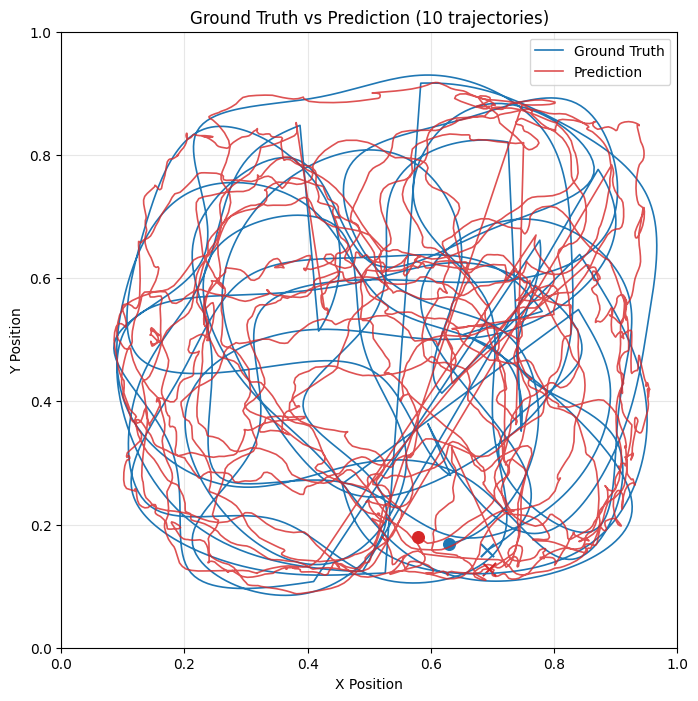

In [22]:
plt.figure(figsize=(8, 8))

# --------------------------------------------------
# Ground Truth
# --------------------------------------------------

plt.plot(
    combined_data["ground_truth"][:, 0],
    combined_data["ground_truth"][:, 1],
    color="tab:blue",
    linewidth=1.2,
    label="Ground Truth",
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

plt.plot(
    combined_data["prediction"][:, 0],
    combined_data["prediction"][:, 1],
    color="tab:red",
    linewidth=1.2,
    alpha=0.8,
    label="Prediction",
)

# --------------------------------------------------
# Starting positions
# --------------------------------------------------

plt.scatter(
    combined_data["ground_truth"][0, 0],
    combined_data["ground_truth"][0, 1],
    color="tab:blue",
    marker="o",
    s=70,
)

plt.scatter(
    combined_data["prediction"][0, 0],
    combined_data["prediction"][0, 1],
    color="tab:red",
    marker="o",
    s=70,
)

# --------------------------------------------------
# Ending positions
# --------------------------------------------------

plt.scatter(
    combined_data["ground_truth"][-1, 0],
    combined_data["ground_truth"][-1, 1],
    color="tab:blue",
    marker="x",
    s=90,
)

plt.scatter(
    combined_data["prediction"][-1, 0],
    combined_data["prediction"][-1, 1],
    color="tab:red",
    marker="x",
    s=90,
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().set_aspect("equal")

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title(
    f"Ground Truth vs Prediction ({len(selected_traj)} trajectories)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

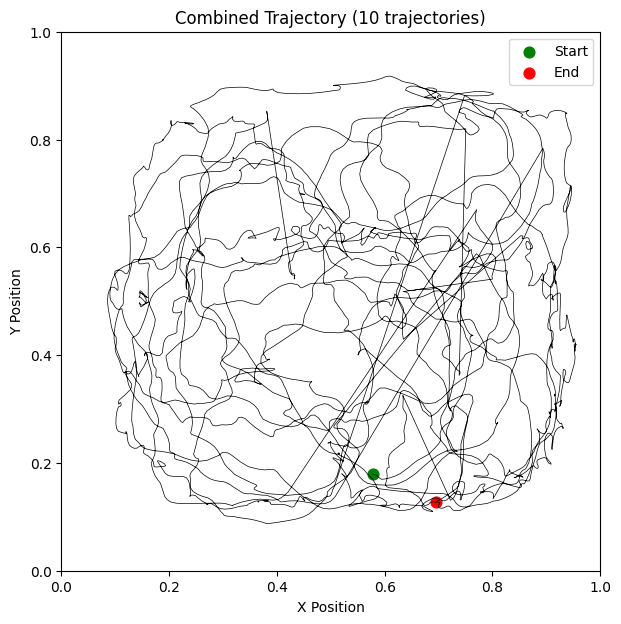

In [21]:
plt.figure(figsize=(7,7))

plt.plot(
    combined_data["positions"][:,0],
    combined_data["positions"][:,1],
    color="black",
    lw=0.5,
)

plt.scatter(
    combined_data["positions"][0,0],
    combined_data["positions"][0,1],
    c="green",
    s=60,
    label="Start",
)

plt.scatter(
    combined_data["positions"][-1,0],
    combined_data["positions"][-1,1],
    c="red",
    s=60,
    label="End",
)

plt.xlim(0,1)
plt.ylim(0,1)

plt.gca().set_aspect("equal")

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title(
    f"Combined Trajectory ({len(selected_traj)} trajectories)"
)

plt.legend()

plt.show()

In [23]:
# --------------------------------------------------
# Occupancy Map
# --------------------------------------------------

occupancy_map = occupancy_map_func(
    combined_data["positions"],
    reso=N_BINS // 2,
    win_len=GAUSSIAN_WINDOW,
    sigma=GAUSSIAN_SIGMA,
)

print("Occupancy Map Shape :", occupancy_map.shape)

Occupancy Map Shape : (80, 80)


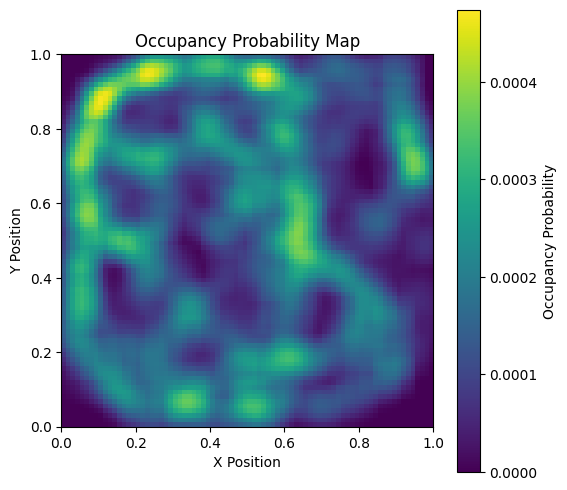

In [24]:
plt.figure(figsize=(6,6))

plt.imshow(
    occupancy_map,
    origin="lower",
    extent=[0,1,0,1],
    cmap="viridis",
)

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title("Occupancy Probability Map")

plt.colorbar(label="Occupancy Probability")

plt.gca().set_aspect("equal")

plt.show()

In [25]:
neuron = 0

responses = combined_data["activations"][:, neuron]

rate_map, extent = build_firing_rate_map(
    responses=responses,
    pos=combined_data["positions"],
    occupancy_map=occupancy_map,
)

print(rate_map.shape)

(80, 80)


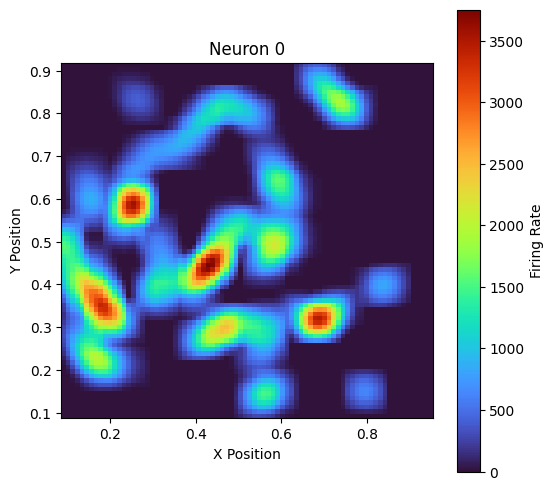

In [26]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    rate_map,
    origin="lower",
    extent=extent,
    cmap="turbo",
)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

ax.set_title(f"Neuron {neuron}")

fig.colorbar(
    im,
    ax=ax,
    label="Firing Rate",
)

plt.show()

In [27]:
EPS = 1e-10

def spatial_information(
    rate_map,
    occupancy_map,
):
    """
    Spatial Information (Skaggs et al., 1993)

    Parameters
    ----------
    rate_map : (N,N)
        Smoothed firing-rate map

    occupancy_map : (N,N)
        Probability occupancy map (sum = 1)

    Returns
    -------
    Spatial Information (bits/spike)
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
        &
        (rate_map > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    if mean_rate < EPS:
        return np.nan

    ratio = r / mean_rate

    SI = np.sum(
        p *
        ratio *
        np.log2(ratio)
    )

    return SI

In [28]:
def sparsity(
    rate_map,
    occupancy_map,
):
    """
    Population Sparsity
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    mean_rate_sq = np.sum(
        p * r**2
    )

    if mean_rate_sq < EPS:
        return np.nan

    return (mean_rate**2) / mean_rate_sq

In [29]:
si = spatial_information(
    rate_map,
    occupancy_map,
)

sp = sparsity(
    rate_map,
    occupancy_map,
)

print(f"Spatial Information : {si:.4f} bits/spike")
print(f"Sparsity           : {sp:.4f}")

Spatial Information : 1.2809 bits/spike
Sparsity           : 0.3253


In [30]:
# --------------------------------------------------
# Analyse every neuron
# --------------------------------------------------

results = []

n_neurons = combined_data["activations"].shape[1]

print(f"Number of neurons : {n_neurons}")

for neuron in range(n_neurons):

    # -----------------------------------------
    # Responses for one neuron
    # -----------------------------------------

    responses = combined_data["activations"][:, neuron]

    # -----------------------------------------
    # Build firing-rate map
    # -----------------------------------------

    rate_map, extent = build_firing_rate_map(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
    )

    # -----------------------------------------
    # Place-cell metrics
    # -----------------------------------------

    si = spatial_information(
        rate_map,
        occupancy_map,
    )

    sp = sparsity(
        rate_map,
        occupancy_map,
    )

    # -----------------------------------------
    # Store results
    # -----------------------------------------

    results.append(
        {
            "Neuron": neuron,
            "Responses": responses,
            "Rate Map": rate_map,
            "Extent": extent,
            "Spatial Information": si,
            "Sparsity": sp,
        }
    )

print(f"\nFinished analysing {len(results)} neurons.")

Number of neurons : 100

Finished analysing 100 neurons.


In [31]:
results = sorted(
    results,
    key=lambda x: x["Spatial Information"],
    reverse=True,
)

print("Top 10 neurons by Spatial Information\n")

for r in results[:10]:

    print(
        f"Neuron {r['Neuron']:3d} | "
        f"SI = {r['Spatial Information']:.3f} | "
        f"Sparsity = {r['Sparsity']:.3f}"
    )

Top 10 neurons by Spatial Information

Neuron  12 | SI = 3.117 | Sparsity = 0.070
Neuron  53 | SI = 2.877 | Sparsity = 0.078
Neuron  96 | SI = 2.863 | Sparsity = 0.090
Neuron  49 | SI = 2.855 | Sparsity = 0.096
Neuron  38 | SI = 2.827 | Sparsity = 0.100
Neuron  73 | SI = 2.739 | Sparsity = 0.105
Neuron  91 | SI = 2.656 | Sparsity = 0.090
Neuron  88 | SI = 2.650 | Sparsity = 0.089
Neuron   9 | SI = 2.650 | Sparsity = 0.095
Neuron  90 | SI = 2.618 | Sparsity = 0.085


In [41]:
# --------------------------------------------------
# Place-cell thresholds
# --------------------------------------------------

SI_THRESHOLD = 0.50

SPARSITY_THRESHOLD = 0.50

place_cells = [

    r

    for r in results

    if (
        r["Spatial Information"] >= SI_THRESHOLD
        and
        r["Sparsity"] <= SPARSITY_THRESHOLD
    )
]

print(f"Place cells found : {len(place_cells)}")

Place cells found : 100


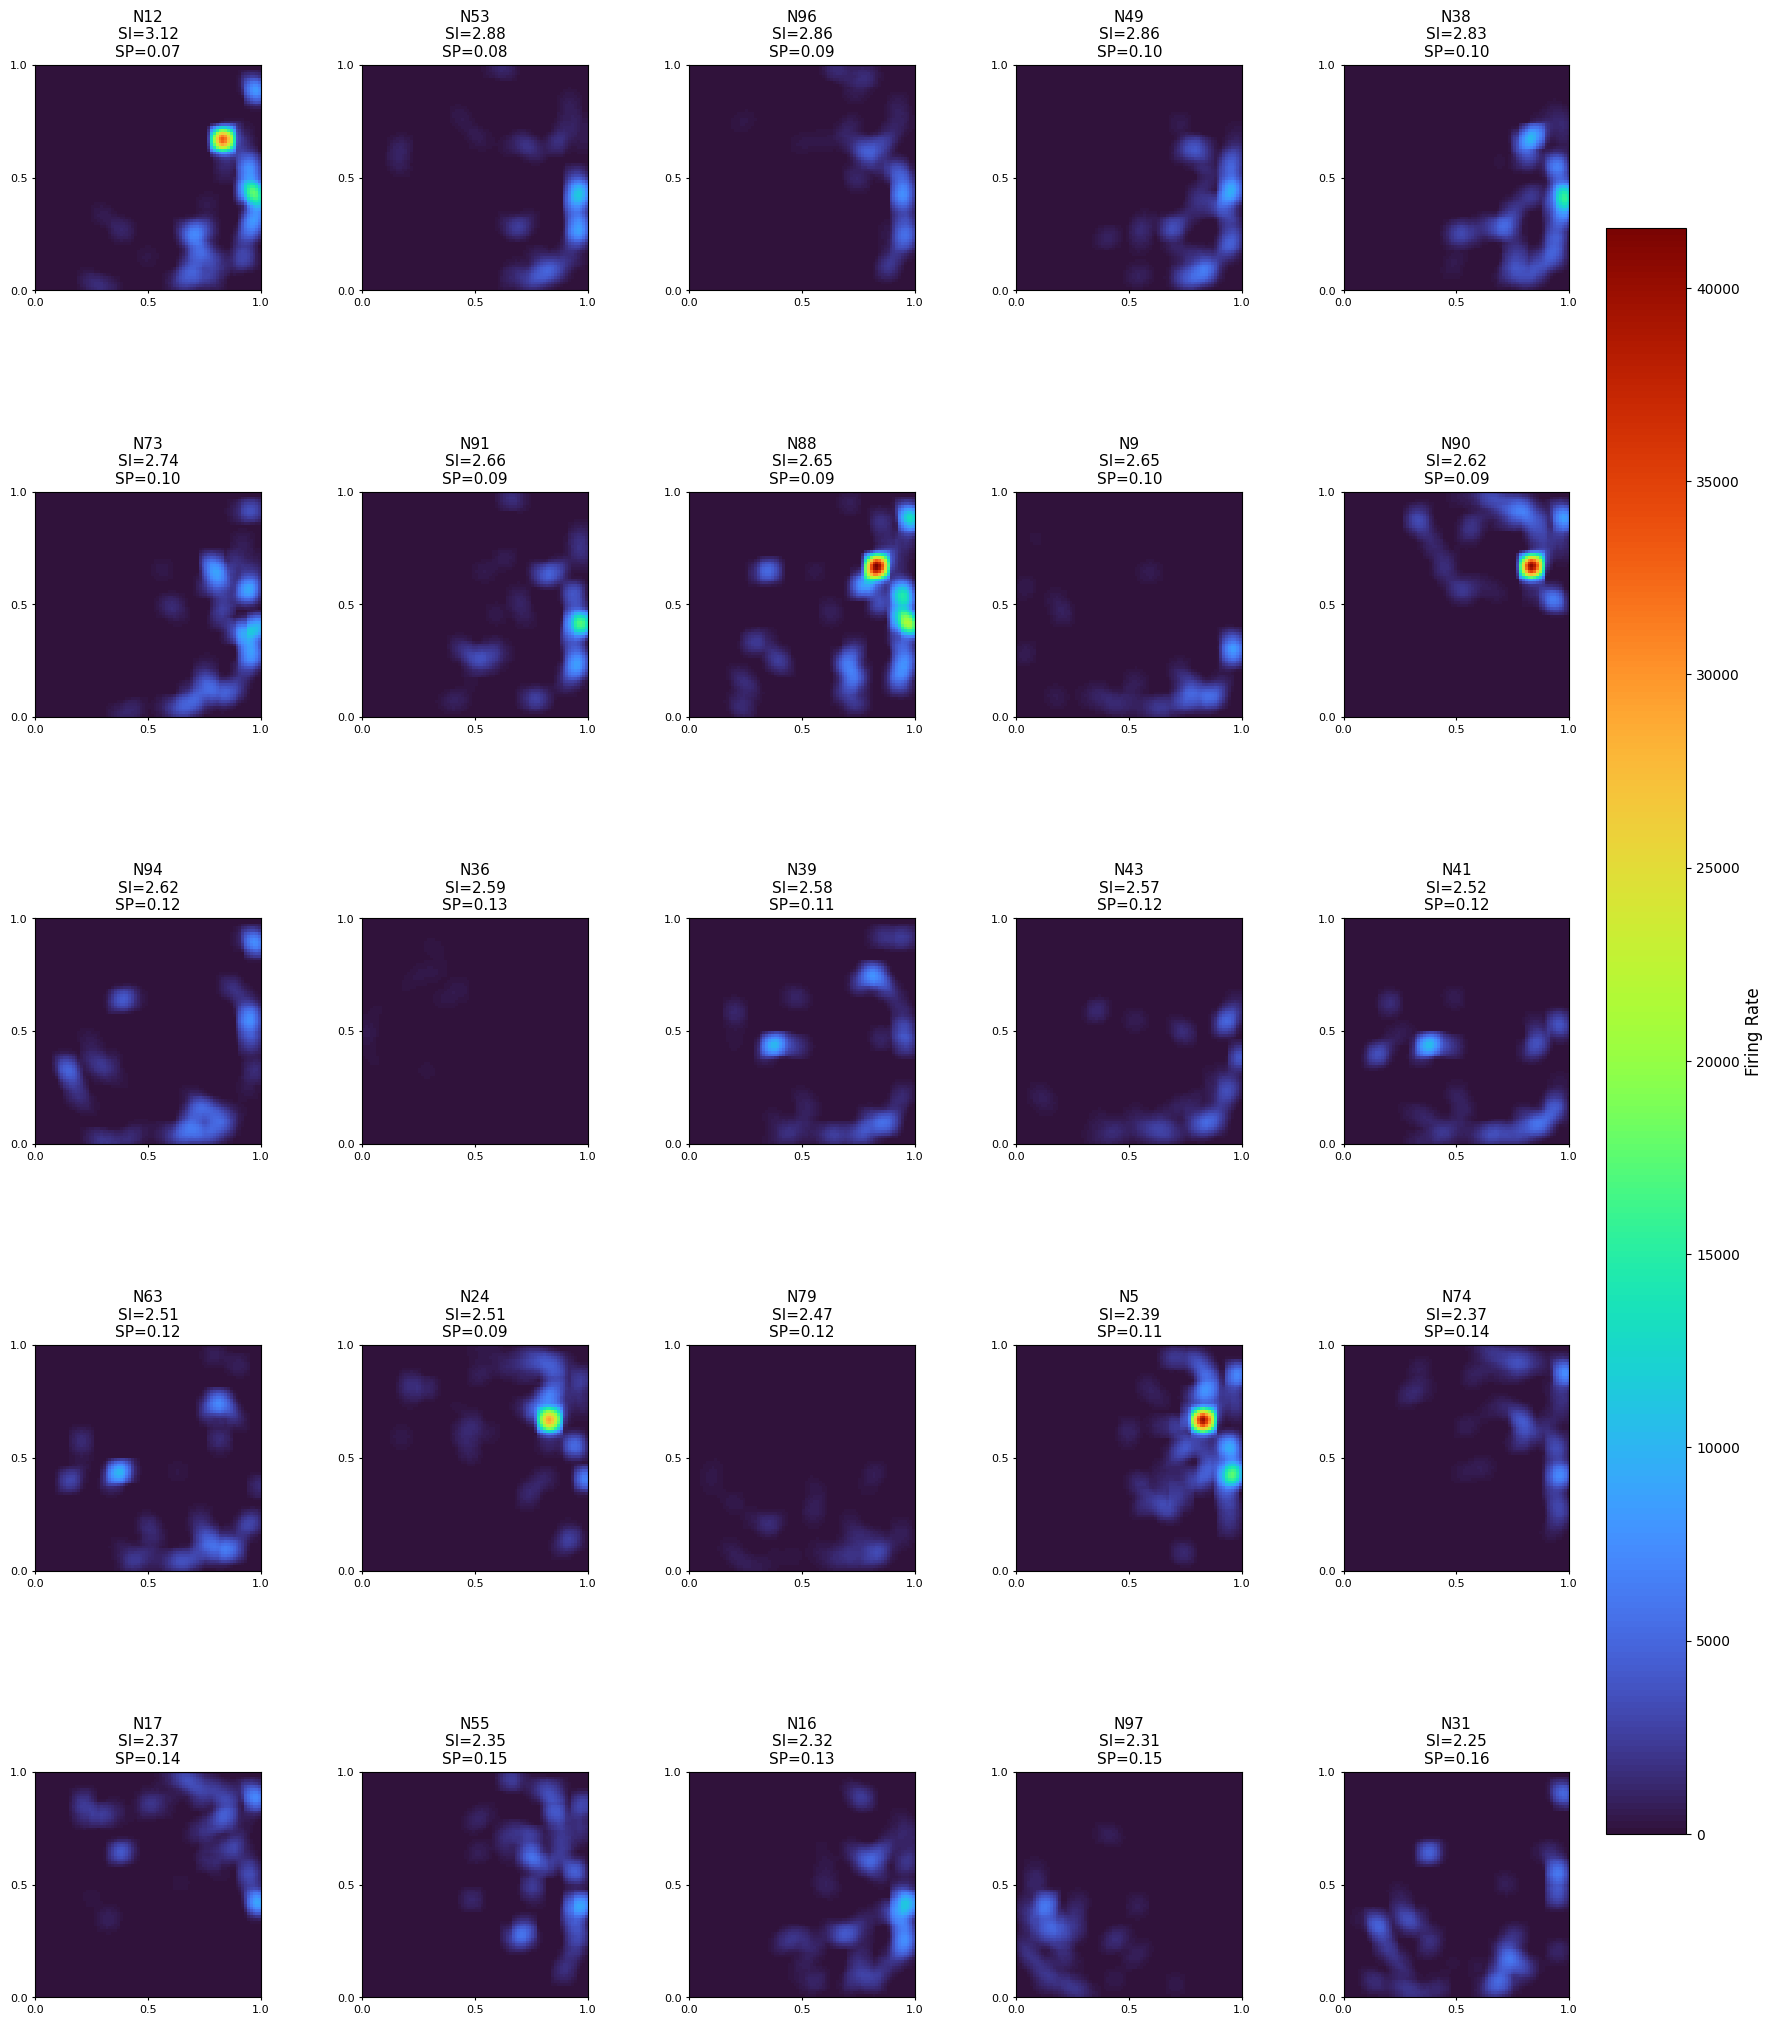

In [42]:
top25 = place_cells[:25]

fig, axes = plt.subplots(
    5,
    5,
    figsize=(22, 22),
)

plt.subplots_adjust(
    left=0.06,
    right=0.90,
    bottom=0.06,
    top=0.95,
    wspace=0.45,
    hspace=0.70,
)

axes = axes.ravel()

vmax = max(
    np.nanmax(r["Rate Map"])
    for r in top25
)

for ax, neuron in zip(axes, top25):

    im = ax.imshow(
        neuron["Rate Map"],
        origin="lower",
        extent=[0, 1, 0, 1],          # Fixed arena
        cmap="turbo",
        aspect="equal",
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
    )

    ax.set_title(
        f"N{neuron['Neuron']}\n"
        f"SI={neuron['Spatial Information']:.2f}\n"
        f"SP={neuron['Sparsity']:.2f}",
        fontsize=11,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

    ax.tick_params(
        labelsize=8,
        length=2,
    )

cbar = fig.colorbar(
    im,
    ax=axes.tolist(),
    shrink=0.82,
    pad=0.02,
)

cbar.set_label(
    "Firing Rate",
    fontsize=12,
)

plt.show()

In [43]:
# --------------------------------------------------
# Analyse every neuron
# --------------------------------------------------

results = []

n_neurons = combined_data["activations"].shape[1]

print(f"Number of neurons : {n_neurons}")

for neuron in range(n_neurons):

    responses = combined_data["activations"][:, neuron]

    rate_map, extent = build_firing_rate_map(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
    )

    si = spatial_information(
        rate_map,
        occupancy_map,
    )

    sp = sparsity(
        rate_map,
        occupancy_map,
    )

    # -----------------------------------------
    # NEW
    # -----------------------------------------

    mean_rate = np.nanmean(rate_map)

    peak_rate = np.nanmax(rate_map)

    active_bins = np.count_nonzero(rate_map > 0)

    # -----------------------------------------

    results.append(
        {
            "Neuron": neuron,
            "Responses": responses,
            "Rate Map": rate_map,
            "Extent": extent,
            "Spatial Information": si,
            "Sparsity": sp,
            "Mean Rate": mean_rate,
            "Peak Rate": peak_rate,
            "Active Bins": active_bins,
        }
    )

print(f"\nFinished analysing {len(results)} neurons.")

Number of neurons : 100

Finished analysing 100 neurons.


In [44]:
results = sorted(
    results,
    key=lambda x: x["Spatial Information"],
    reverse=True,
)

print("\nTop 10 neurons\n")

for r in results[:10]:

    print(
        f"N{r['Neuron']:3d} | "
        f"SI={r['Spatial Information']:.3f} | "
        f"SP={r['Sparsity']:.3f} | "
        f"Mean={r['Mean Rate']:.1f} | "
        f"Peak={r['Peak Rate']:.1f} | "
        f"Bins={r['Active Bins']}"
    )


Top 10 neurons

N 12 | SI=3.117 | SP=0.070 | Mean=870.9 | Peak=33227.8 | Bins=2007
N 53 | SI=2.877 | SP=0.078 | Mean=399.6 | Peak=11454.5 | Bins=2124
N 96 | SI=2.863 | SP=0.090 | Mean=329.1 | Peak=7567.6 | Bins=2035
N 49 | SI=2.855 | SP=0.096 | Mean=463.3 | Peak=9600.4 | Bins=2097
N 38 | SI=2.827 | SP=0.100 | Mean=636.3 | Peak=15712.7 | Bins=1978
N 73 | SI=2.739 | SP=0.105 | Mean=642.7 | Peak=11460.9 | Bins=2040
N 91 | SI=2.656 | SP=0.090 | Mean=468.8 | Peak=17047.2 | Bins=2160
N 88 | SI=2.650 | SP=0.089 | Mean=1229.8 | Peak=41541.0 | Bins=2675
N  9 | SI=2.650 | SP=0.095 | Mean=265.0 | Peak=8329.2 | Bins=1888
N 90 | SI=2.618 | SP=0.085 | Mean=709.7 | Peak=40687.8 | Bins=1887
